In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import yaml
import os
import glob
import random
import time
from collections import defaultdict

os.environ["XLA_FLAGS"] = "--xla_gpu_deterministic_ops=true --xla_gpu_autotune_level=0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

sys.path.append("..")

import wandb
# import jax
from dataclasses import asdict
import numpy as np
import pandas as pd
import tqdm
# from agents import agents
# from ml_collections import FrozenConfigDict
#  from utils.datasets import Dataset, GCDataset, HGCDataset
# from utils.evaluation import evaluate
# from utils.flax_utils import restore_agent, save_agent
# from utils.log_utils import CsvLogger, get_exp_name, get_wandb_video, setup_wandb
from utils.config import GCTTTConfig, load_config
import matplotlib.pyplot as plt
import importlib


In [3]:
import re

# Pattern improved: randbatch matches "RANDOMBATCH" only (not RANDOMBATCHCH), -mc is optional
# Now also matches an optional FT- prefix before the goals, storing is_finetuned (True if 'FT-' present)
# Optional -lr after mc_quantile, which can be a normal float or scientific notation (e.g., -lr3e-05)
IQL_NAME_PATTERN = (
    r"^"
    r"(?:(?P<is_finetuned>FT)-)?"
    # Match optional ALL-GOALS, ALLGOALS, ALL, TEST-GOALS, TESTGOALS, or TEST (with or without -GOALS)
    r"(?:(?P<goals>ALL|TEST)(?:-GOALS)?-)?"
    r"(?:(?P<env>antmaze)-)?"
    r"(?:(?P<policy_extraction>ddpgbc)-)?"
    r"(?P<pretraining>PT|FX|RX)"
    r"(?:-(?P<inner_steps>\d+)-(?P<meta_batch_size>\d+))?"
    r"(?:-mc(?P<mc_quantile>[\d.]+))?"
    r"(?:-m_(?P<merging_eps>[\d.]+))?"
    r"(?:-lr(?P<lr>(?:[\d.]+|[\d.]+e[+\-]?\d+)))?"
    r"(?:-ilr(?P<ilr>(?:[\d.]+|[\d.]+e[+\-]?\d+)))?"
    r"$"
)

assert re.match(IQL_NAME_PATTERN, "TEST-antmaze-ddpgbc-FX-1-1-mc0.2-lr0.0003-ilr0.0003") is not None
assert re.match(IQL_NAME_PATTERN, "TEST-antmaze-ddpgbc-PT-mc0.2-lr0.0003-ilr0.0003") is not None
assert re.match(IQL_NAME_PATTERN, "TEST-antmaze-ddpgbc-RX-1-1-mc0.2-lr0.0003-ilr0.0003") is not None
assert re.match(IQL_NAME_PATTERN, "antmaze-ddpgbc-PT") is not None

In [4]:
# Fetch detailed metrics and history for each run, and extract metrics at specific timesteps
import re
import os
from typing import Dict, Tuple, Any
import json


def parse_group_name(group_name: str):

    match = re.match(IQL_NAME_PATTERN, group_name)

    if match:

        params_dict = match.groupdict()

        if 'goals' not in params_dict:
            params_dict['goals'] = "TEST"
        if 'env' not in params_dict or params_dict['env'] is None:
            params_dict['env'] = "pointmaze"
        if 'randbatch' in params_dict and params_dict['randbatch'] is not None:
            params_dict['goals'] = "RANDOM"
            del params_dict['randbatch']

        # Default mc_quantile is 0.2 (optimality)
        if 'mc_quantile' not in params_dict or params_dict['mc_quantile'] is None:
            params_dict['mc_quantile'] = 0.2
        else:
            params_dict['mc_quantile'] = float(params_dict['mc_quantile'])

        if 'lr' not in params_dict or params_dict['lr'] is None:
            params_dict['lr'] = 3e-04
        else:
            params_dict['lr'] = float(params_dict['lr'])
        if 'ilr' not in params_dict or params_dict['ilr'] is None:
            params_dict['ilr'] = 3e-04
        else:
            params_dict['ilr'] = float(params_dict['ilr'])

        if params_dict['pretraining'] == "RX":
            params_dict['pretraining'] = "REPTILE"
        elif params_dict['pretraining'] == "FX":
            params_dict['pretraining'] = "FOMAML"

        if 'merging_eps' not in params_dict or params_dict['merging_eps'] is None:
            if params_dict['pretraining'] == "REPTILE":
                params_dict['merging_eps'] = 1.0
        else:
            params_dict['merging_eps'] = float(params_dict['merging_eps'])

        # Convert numeric fields to int if present
        for k in ['inner_steps', 'meta_batch_size']:
            if k in params_dict and params_dict[k] is not None:
                params_dict[k] = int(params_dict[k])

        print(params_dict)
        return params_dict
    # If we get here, we failed to parse the group name
    raise AssertionError(f"Failed to parse group name: {group_name}")




def fetch_group_runs(group_name: str, download_data: bool = False) -> Tuple[Dict[str, Any], Dict[int, pd.DataFrame]]:
    """
    Fetch all runs for a given group name and return settings and results.

    Results are collected from a directory structured as:
    notebooks/results_eval/{group_name}/results_seed{N}.csv

    Returns:
        tuple[dict, dict]: A tuple containing two dictionaries.
            - The first dictionary contains the settings extracted from the group name.
            - The second dictionary contains the results for each run, keyed by seed.
    """
    # Parse settings from group_name (same as above in the notebook)
    settings = parse_group_name(group_name)

    results_dir = os.path.join("results_eval", group_name)
    results = {}

    if not os.path.isdir(results_dir):
        raise FileNotFoundError(f"Results directory not found: {results_dir}")

    result_files = glob.glob(os.path.join(results_dir, "results_seed*.csv"))
    if not result_files:
        raise FileNotFoundError(f"No result files found in: {results_dir}")

    for file in result_files:
        # Expect filename contains ...results_seedN.csv
        basename = os.path.basename(file)
        try:
            seed_str = basename.split("results_seed")[1].split(".csv")[0]
            seed = int(seed_str)
        except Exception as e:
            # Skip files with unexpected naming
            continue
        try:
            df = pd.read_csv(file)
            # Try to convert numeric columns to float
            for col in df.columns:
                if col.endswith("_success") or col in ["overall_success"]:
                    df[col] = pd.to_numeric(df[col], errors="coerce")
                if col in ["step", "TTT_steps"]:
                    df[col] = pd.to_numeric(df[col], errors="coerce", downcast="integer")
            results[seed] = df
        except Exception as e:
            print(f"Failed to load {file}: {e}")
            results[seed] = pd.DataFrame()  # put empty so later code will work

    return settings, results

In [5]:
import matplotlib.pyplot as plt
from typing import Any, Union, Tuple
from collections import defaultdict


def get_mean_std_for_all_steps(settings: dict, results: dict[int, pd.DataFrame], result_col="overall_success"):
    """
    Instead of taking group_name and results, takes settings and results as from fetch_group_runs.
    """
    # Collect all unique steps across all seeds
    all_steps = sorted(set(np.concatenate([df['step'].values for df in results.values() if not df.empty])))
    if not all_steps:
        raise ValueError(f"No data for group: {settings}")

    # Build a matrix: rows=seeds, columns=steps, values=overall_success (NaN if missing)
    seed_list = sorted(results.keys())
    overall_success_matrix = np.full((len(seed_list), len(all_steps)), np.nan)

    for i, seed in enumerate(seed_list):
        df = results[seed]
        if df.empty:
            continue
        step_to_success = dict(zip(df['step'], df[result_col]))
        for j, step in enumerate(all_steps):
            if step in step_to_success:
                overall_success_matrix[i, j] = step_to_success[step]

    # Compute mean and std across seeds (ignore NaNs)
    mean_success = np.nanmean(overall_success_matrix, axis=0)
    std_success = np.nanstd(overall_success_matrix, axis=0)

    return all_steps, mean_success, std_success


def plot_overall_success_for_groups(
    groups_dict,
    baselines: dict[int, float] = None,
    result_col: str = "overall_success"
):
    """
    Plot the mean and standard deviation of a result metric (e.g., overall_success)
    as a function of training steps for several experiment groups.

    For each unique TTT_steps value found in the results of a group, plot a separate line (mean ± std across seeds).
    Shading denotes ± one standard deviation. Optionally, plot horizontal lines for baselines.

    Args:
        groups_dict: dictionary where each key is a label and each value is a dictionary with a "groups" key
            containing a list of group names.
        baselines (dict[int, float], optional): horizontal lines for given TTT_steps values.
        result_col (str, optional): result column to plot.

    Behavior:
        - For each TTT_steps value present among results, plot a separate line per group.
    """
    plt.figure(figsize=(8, 5))
    pretraining = set()

    for idx, (group_label, group_info) in enumerate(groups_dict.items()):
        group_name = group_info["groups"][0]
        settings, results = fetch_group_runs(group_name)
        pretraining.add(settings.get("pretraining", None))
        color_base = f"C{idx % 10}"

        # Determine unique TTT_steps present across all seeds' DataFrames
        ttt_to_indices = {}
        for seed, df in results.items():
            if df.empty or 'TTT_steps' not in df.columns:
                continue
            for ttt in df['TTT_steps'].unique():
                ttt_to_indices.setdefault(ttt, set()).add(seed)

        # Plot one line per TTT_steps value found in results
        for j, (ttt_steps_value, seed_set) in enumerate(sorted(ttt_to_indices.items())):
            # Collect all seeds with this TTT_steps value; build results subset
            seeds_with_ttt = list(seed_set)
            if not seeds_with_ttt:
                continue
            # Aggregate df for only these seeds and only rows where TTT_steps == ttt_steps_value
            subgroup_results = {
                seed: df[df['TTT_steps'] == ttt_steps_value] if not df.empty else pd.DataFrame()
                for seed, df in results.items() if seed in seeds_with_ttt
            }
            # Possibly different color for each line of this group
            color = color_base if len(ttt_to_indices) == 1 else f"C{(idx*4 + j) % 10}"

            # Optionally plot baseline for this TTT_steps value
            if baselines is not None and ttt_steps_value in baselines:
                plt.axhline(
                    y=baselines[ttt_steps_value],
                    color=color,
                    linestyle='--'
                )

            # Aggregate results across chosen seeds and steps
            all_steps, mean_success, std_success = get_mean_std_for_all_steps(
                settings, subgroup_results, result_col=result_col)
            label = f"{group_label} (TTT={ttt_steps_value})" if ttt_steps_value is not None else group_label
            plt.plot(
                all_steps, mean_success, label=label, color=color
            )
            plt.fill_between(
                all_steps, mean_success - std_success, mean_success + std_success,
                color=color, alpha=0.2)

    plt.xlabel('Pretraining Steps')
    plt.ylabel('Overall Success')
    plt.title(f"Algo: {pretraining}")
    plt.legend()
    plt.grid(True)
    plt.show()


def get_best_mean_success_and_std(settings: dict, results: dict[int, pd.DataFrame], result_col="overall_success") -> Tuple[int, float, float]:
    """
    Compute the maximum of the mean overall_success across steps.

    Args:
        settings: dict: settings of the group (from parse_group_name)
        results: dict[int, pd.DataFrame]: dict of seed to dataframe of results
    Returns:
        tuple[int, float, float]: (TTT_steps, max_mean_success, std_at_max)
    """
    all_steps = sorted(set(np.concatenate([df['step'].values for df in results.values() if not df.empty])))
    if not all_steps:
        raise AssertionError(f"No data for group: {settings}")

    seed_list = sorted(results.keys())
    overall_success_matrix = np.full((len(seed_list), len(all_steps)), np.nan)

    for i, seed in enumerate(seed_list):
        df = results[seed]
        if df.empty:
            continue
        step_to_success = dict(zip(df['step'], df[result_col]))
        for j, step in enumerate(all_steps):
            if step in step_to_success:
                overall_success_matrix[i, j] = step_to_success[step]

    mean_success = np.nanmean(overall_success_matrix, axis=0)
    std_success = np.nanstd(overall_success_matrix, axis=0)

    if np.all(np.isnan(mean_success)):
        raise AssertionError(f"All mean_success are NaN for group: {settings}")
    max_idx = np.nanargmax(mean_success)
    max_mean_success = mean_success[max_idx]
    std_at_max = std_success[max_idx]

    return max_mean_success, std_at_max

def get_algo_color(group_key):
    # If geom is False, override color to black
    if group_key[4] is False or group_key[5] == 1.0:
        return "black"
    if group_key[1] == "FOMAML":
        return "green"
    elif group_key[1] == "MAML":
        return "blue"
    elif group_key[1] == "PT":
        return "purple"
    elif group_key[1] == "REPTILE":
        return "red"
    return None

def get_linestyle_and_dot_type(group_key):
    if group_key[0] == "ALL":
        return "solid", "o"
    elif group_key[0] == "TEST":
        return "dashed", "s"
    elif group_key[0] == "RANDOM":
        return "dotted", "D"
    return "solid", "o"

def plot_max_overall_success_vs_ttt_steps(
    group_results: dict,
    result_col="overall_success",
    verbose: bool = False,
    title: str = None
):
    """
    For all (settings,results) pairs in group_results, plot the maximum of the mean overall_success across steps.
    Groups are defined by the tuple (goals, pretraining, inner_steps, meta_batch_size).
    For each group, plot a line: X-axis is TTT_steps, Y-axis is max mean overall_success.
    The label for each line is the group fields.
    Error bars (std across seeds at the max mean step) are shown using fill_between.

    If group_results is a dict, you can provide value as either a list of (settings, results) tuples
    or a dict with keys:
        - 'groups': list of (settings, results) tuples (required)
        - 'color', 'linestyle', 'dot_type': optional (for plot line customization)
    """
    group_points = defaultdict(list)
    group_plotopts = {}

    def append_group_points(settings: dict, results: dict[int, pd.DataFrame], label: str = None):
        # Extract grouping fields
        goals = settings.get("goals", None)
        pretraining = settings.get("pretraining", None)
        inner_steps = settings.get("inner_steps", None)
        meta_batch_size = settings.get("meta_batch_size", None)
        mc_quantile = float(settings.get("mc_quantile", 0.2))

        info = f"goals={goals}, " \
            f"pretraining={pretraining}, " \
            f"inner_steps={inner_steps}, " \
            f"meta_batch_size={meta_batch_size}, " \
            f"mc_quantile={mc_quantile}"

        # "ttt_steps" is a column only in the latest implementation format
        first_df = next(iter(results.values()))
        for ttt_steps in [0, 5, 10, 20, 50, 100, 200]:
            # Overwrite TTT_steps in settings
            settings["TTT_steps"] = ttt_steps
            # Copy all DFs filtered by ttt_steps
            filtered_results = {k: v[v['TTT_steps'] == ttt_steps] for k, v in results.items()}
            if len(filtered_results) == 0 or all(df.empty for df in filtered_results.values()):
                if verbose:
                    print(f"[Skipping] No filtered results for TTT_steps={ttt_steps}, group={label}")
                continue
            if verbose:
                print(info + f" TTT_steps={ttt_steps}")
            max_mean_success, std_at_max = get_best_mean_success_and_std(settings, filtered_results, result_col=result_col)
            group_points[label].append((ttt_steps, max_mean_success, std_at_max, label))

    # If group_results is a dict, extract the values and custom plotting options if present
    for idx, (group_label, group_info) in enumerate(group_results.items()):
        group_name = group_info["groups"][0]
        settings, results = fetch_group_runs(group_name)
        append_group_points(settings, results, label=group_label)
        plotopts = {}
        for k in ("color", "linestyle", "dot_type"):
            if k in group_info:
                plotopts[k] = group_info[k]
        if plotopts:
            group_plotopts[group_label] = plotopts

    if verbose:
        print(group_points)

    plt.figure(figsize=(8, 5))
    color_map = {}
    for idx, (label, points) in enumerate(sorted(group_points.items())):
        points_sorted = sorted(points, key=lambda x: x[0])
        ttt_steps_sorted = [p[0] for p in points_sorted]
        max_mean_success_sorted = [p[1] for p in points_sorted]
        if verbose:
            print(list(zip(ttt_steps_sorted, max_mean_success_sorted)))
        std_at_max_sorted = [p[2] for p in points_sorted]

        plotopts = group_plotopts.get(label, {})

        color = plotopts.get("color", None)
        if color is None:
            color = get_algo_color(label)
            if color is None:
                color = f"C{idx % 10}"
        color_map[label] = color

        linestyle = plotopts.get("linestyle", None)
        dot_type = plotopts.get("dot_type", None)
        if linestyle is None or dot_type is None:
            _auto_ls, _auto_dot = get_linestyle_and_dot_type(label)
            linestyle = linestyle if linestyle is not None else _auto_ls
            dot_type = dot_type if dot_type is not None else _auto_dot

        plt.plot(
            ttt_steps_sorted,
            max_mean_success_sorted,
            marker=dot_type,
            linestyle=linestyle,
            color=color,
            label=label,
            alpha=0.9,
        )
        lower = np.array(max_mean_success_sorted) - np.array(std_at_max_sorted)
        upper = np.array(max_mean_success_sorted) + np.array(std_at_max_sorted)
        plt.fill_between(
            ttt_steps_sorted,
            lower,
            upper,
            color=color,
            alpha=0.2,
        )

    plt.xlabel('TTT_steps')
    plt.ylabel('Max Mean Overall Success')
    if title is not None:
        plt.title(title)
    else:
        plt.title(f'Max {result_col} vs TTT_steps')
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()


{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'FOMAML', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 3e-05, 'ilr': 3e-05}


{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'FOMAML', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.0003, 'ilr': 3e-05}
{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'FOMAML', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.0003, 'ilr': 0.0003}


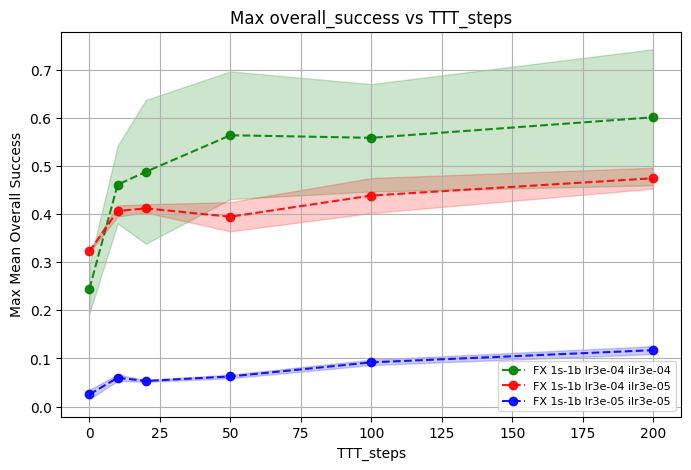

In [6]:
ANTMAZE_FROM_SCRATCH = {}
for algo in "RX", "FX":
    ANTMAZE_FROM_SCRATCH[algo] = {
        f"{algo} 1s-1b lr3e-05 ilr3e-05": {
            "groups": [
                f"TEST-antmaze-ddpgbc-{algo}-1-1-mc0.2-lr3e-05-ilr3e-05"
            ],
            "color": "blue",
            "linestyle": "--",
            "dot_type": "o",
        },

        f"{algo} 1s-1b lr3e-04 ilr3e-05": {
            "groups": [
                f"TEST-antmaze-ddpgbc-{algo}-1-1-mc0.2-lr0.0003-ilr3e-05"
            ],
            "color": "red",
            "linestyle": "--",
            "dot_type": "o",
        },

        f"{algo} 1s-1b lr3e-04 ilr3e-04": {
            "groups": [
                f"TEST-antmaze-ddpgbc-{algo}-1-1-mc0.2-lr0.0003-ilr0.0003"
            ],
            "color": "green",
            "linestyle": "--",
            "dot_type": "o",
        },

    }

ANTMAZE_FROM_SCRATCH["PT"] = {
    "PT lr3e-05": {
        "groups": [
            "TEST-antmaze-ddpgbc-PT-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },
    "PT lr3e-04": {
        "groups": [
            "TEST-antmaze-ddpgbc-PT-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },
    "PT lr3e-03": {
        "groups": [
            "TEST-antmaze-ddpgbc-PT-mc0.2-lr0.003-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },
}
# plot_overall_success_for_groups(ANTMAZE_FROM_SCRATCH["FX"])
plot_max_overall_success_vs_ttt_steps(ANTMAZE_FROM_SCRATCH["FX"])

{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 5, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 5, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 3e-05, 'ilr': 3e-05}


{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 10, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 10, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 3e-05, 'ilr': 3e-05}
{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 20, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 3e-05, 'ilr': 3e-05}
{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 20, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 

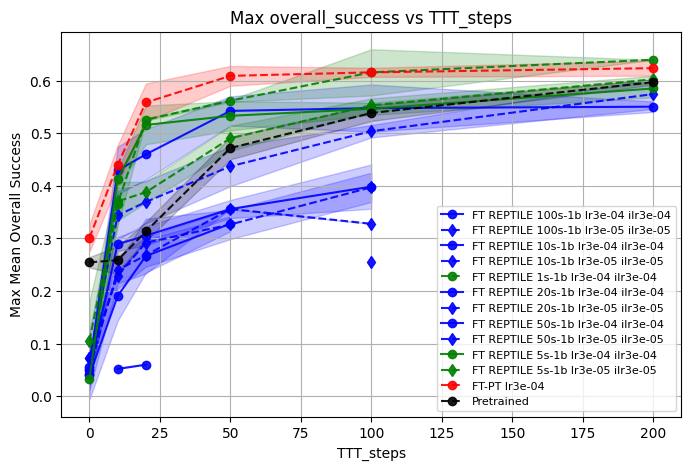

In [8]:
ANTMAZE_FINETUNED = {}
ANTMAZE_FINETUNED["FX"] = {
        f"FT FOMAML 1s-1b lr3e-05 ilr3e-05": {
            "groups": [
                f"FT-TEST-antmaze-ddpgbc-FX-1-1-mc0.2-lr3e-05-ilr3e-05"
            ],
            "color": "blue",
            "linestyle": "--",
            "dot_type": "o",
        },

        f"FT FOMAML 1s-1b lr3e-04 ilr3e-05": {
            "groups": [
                f"FT-TEST-antmaze-ddpgbc-FX-1-1-mc0.2-lr0.0003-ilr3e-05"
            ],
            "color": "red",
            "linestyle": "--",
            "dot_type": "o",
        },

        f"FT FOMAML 1s-1b lr3e-04 ilr3e-04": {
            "groups": [
                f"FT-TEST-antmaze-ddpgbc-FX-1-1-mc0.2-lr0.0003-ilr0.0003"
            ],
            "color": "green",
            "linestyle": "--",
            "dot_type": "o",
        },
    }

ANTMAZE_FINETUNED["RX"] = {
    f"FT REPTILE 1s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    f"FT REPTILE 5s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    f"FT REPTILE 5s-1b lr3e-05 ilr3e-05": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-5-1-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    f"FT REPTILE 10s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },

    f"FT REPTILE 10s-1b lr3e-05 ilr3e-05": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-10-1-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "d",
    },

    f"FT REPTILE 20s-1b lr3e-05 ilr3e-05": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-20-1-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "d",
    },

    f"FT REPTILE 20s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },

    f"FT REPTILE 50s-1b lr3e-05 ilr3e-05": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-50-1-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "d",
    },

    f"FT REPTILE 50s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },

    f"FT REPTILE 100s-1b lr3e-05 ilr3e-05": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-100-1-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "d",
    },

    f"FT REPTILE 100s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },



    "Pretrained": {
        "groups": [
            "antmaze-ddpgbc-PT"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "FT-PT lr3e-04": {
        "groups": [
            "FT-TEST-antmaze-ddpgbc-PT-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },
}

ANTMAZE_FINETUNED["PT"] = {
    "FT-PT lr3e-05": {
        "groups": [
            "FT-TEST-antmaze-ddpgbc-PT-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },
    "FT-PT lr3e-04": {
        "groups": [
            "FT-TEST-antmaze-ddpgbc-PT-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },
    "FT-PT lr3e-03": {
        "groups": [
            "FT-TEST-antmaze-ddpgbc-PT-mc0.2-lr0.003-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained": {
        "groups": [
            "antmaze-ddpgbc-PT"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
}


ANTMAZE_COMPARISON_FT = {
    f"FT-FOMAML 1s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-FX-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },
    f"FT-REPTILE 1s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },
    "FT-PT lr3e-04": {
        "groups": [
            "FT-TEST-antmaze-ddpgbc-PT-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },
}
# plot_overall_success_for_groups(ANTMAZE_FROM_SCRATCH["FX"])
plot_max_overall_success_vs_ttt_steps(ANTMAZE_FINETUNED["RX"])

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 3e-05, 'ilr': 3e-05}
{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 3e-05}
{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}


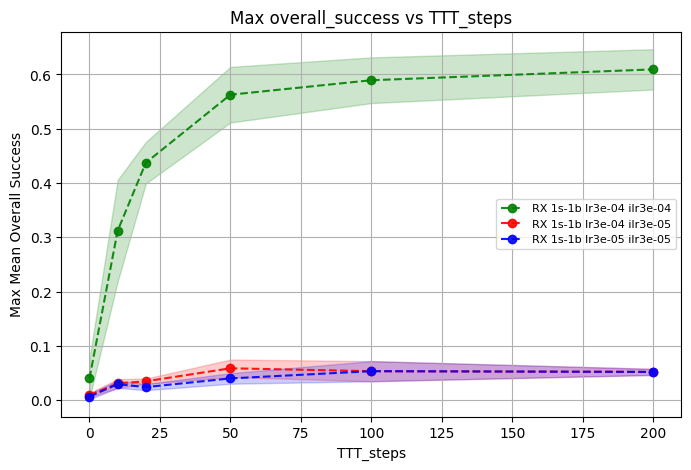

In [8]:
plot_max_overall_success_vs_ttt_steps(ANTMAZE_FROM_SCRATCH["RX"])

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'FOMAML', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'PT', 'inner_steps': None, 'meta_batch_size': None, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.0003, 'ilr': 0.0003}


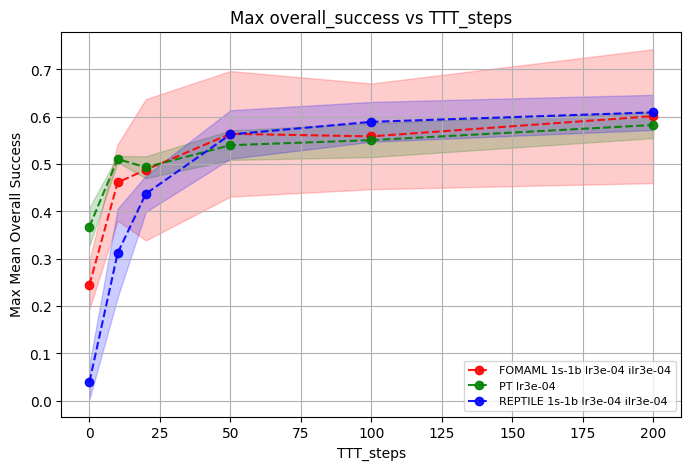

In [10]:
ANTMAZE_COMPARISON = {
    f"FOMAML 1s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"TEST-antmaze-ddpgbc-FX-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },
    f"REPTILE 1s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"TEST-antmaze-ddpgbc-RX-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },
    "PT lr3e-04": {
        "groups": [
            "TEST-antmaze-ddpgbc-PT-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },
}
# plot_overall_success_for_groups(ANTMAZE_FROM_SCRATCH["FX"])
plot_max_overall_success_vs_ttt_steps(ANTMAZE_COMPARISON)

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 3e-05, 'ilr': 3e-05}


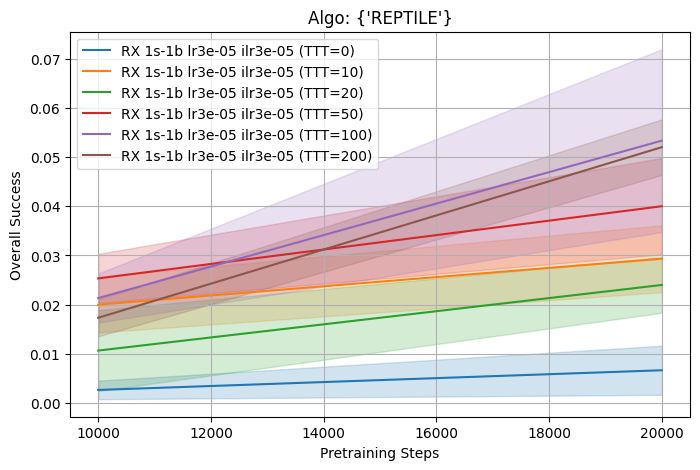

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 3e-05}


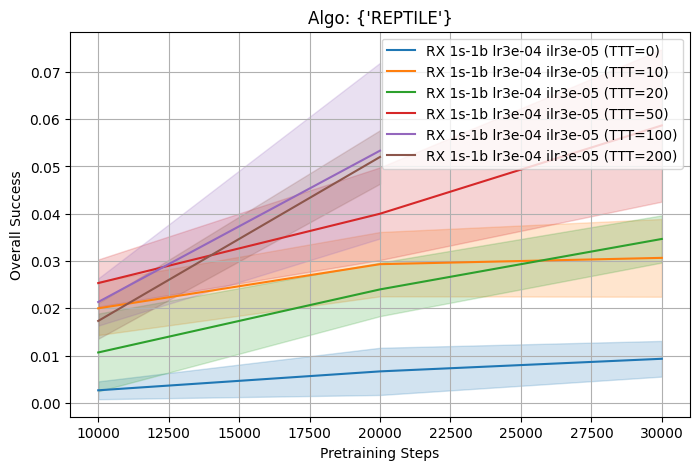

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}


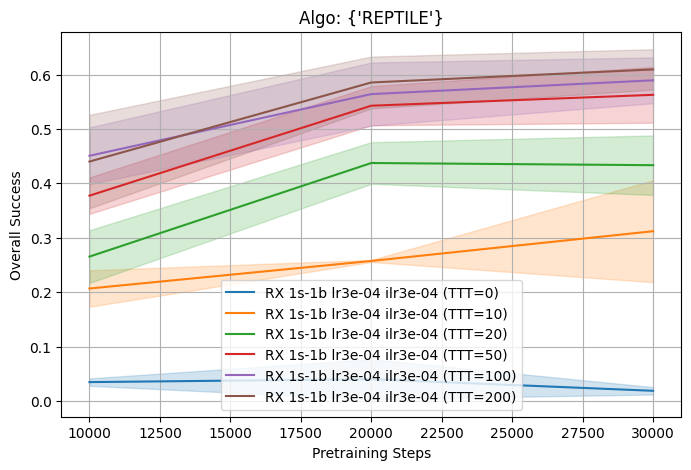

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'FOMAML', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 3e-05, 'ilr': 3e-05}


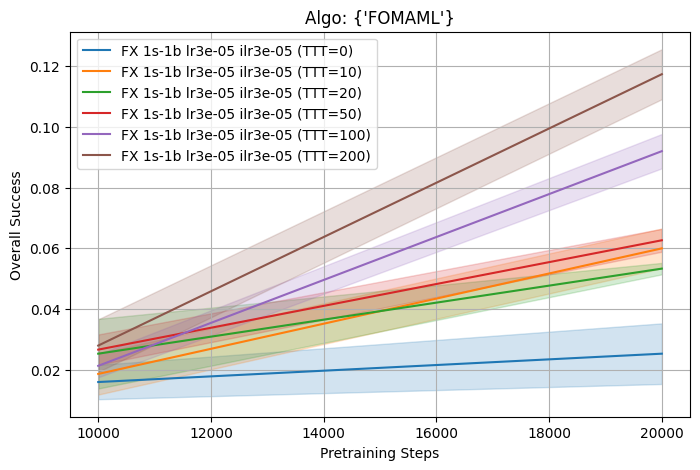

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'FOMAML', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.0003, 'ilr': 3e-05}


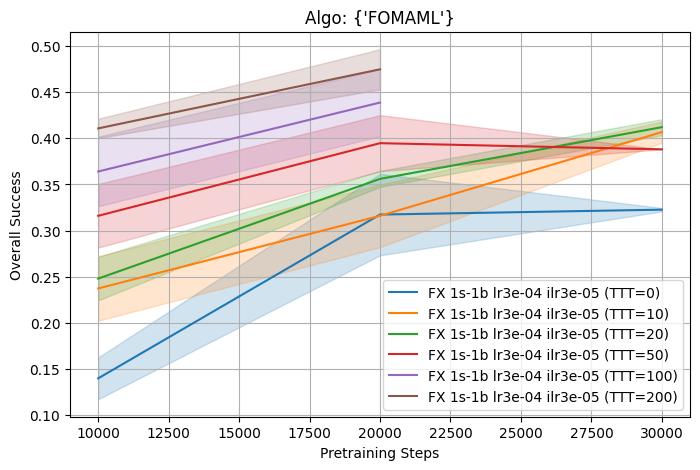

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'FOMAML', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.0003, 'ilr': 0.0003}


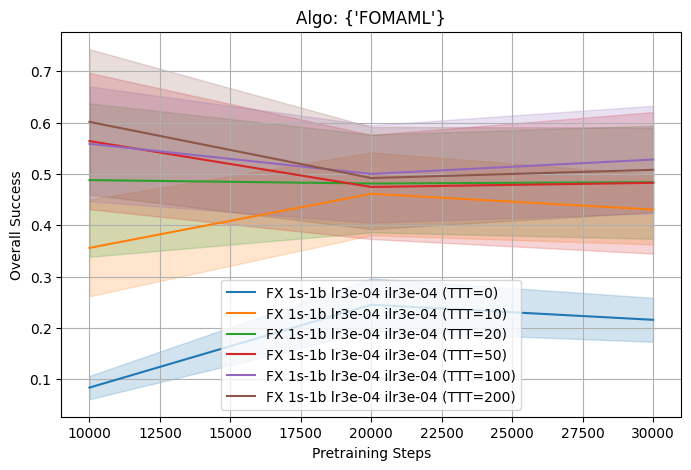

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'PT', 'inner_steps': None, 'meta_batch_size': None, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 3e-05, 'ilr': 3e-05}


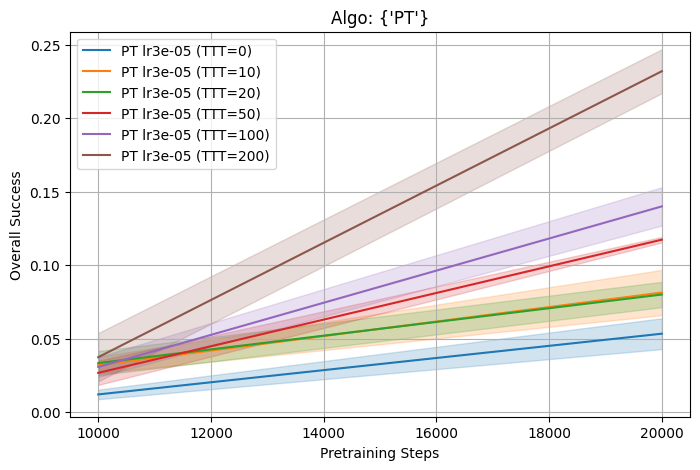

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'PT', 'inner_steps': None, 'meta_batch_size': None, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.0003, 'ilr': 0.0003}


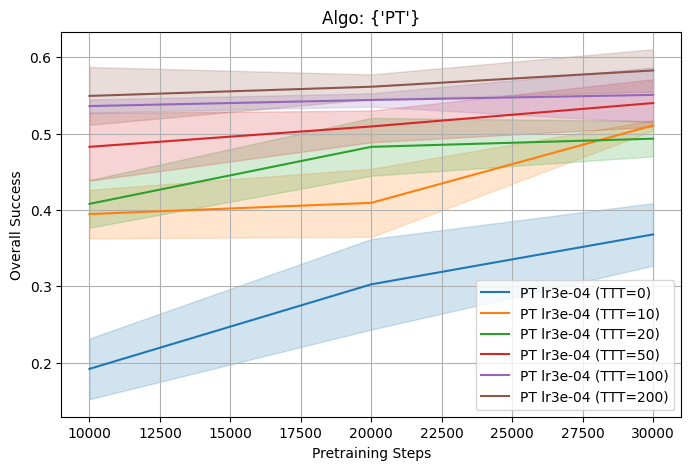

{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'PT', 'inner_steps': None, 'meta_batch_size': None, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.003, 'ilr': 0.003}


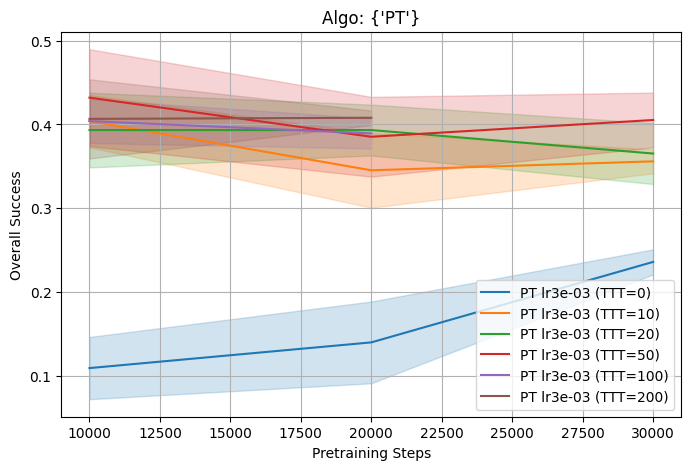

In [ ]:
for algo in "RX", "FX", "PT":
    for run_name, run_info in ANTMAZE_FROM_SCRATCH[algo].items():
        plot_overall_success_for_groups({run_name: run_info})
# plot_overall_success_for_groups(ANTMAZE_FROM_SCRATCH["FX"])


{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 1, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 5, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 10, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'REPTILE', 'inner_steps': 20, 'meta_batch_size': 1, 'mc_quantile': 0.2, 'merging_eps': 1.0, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': None, 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining'

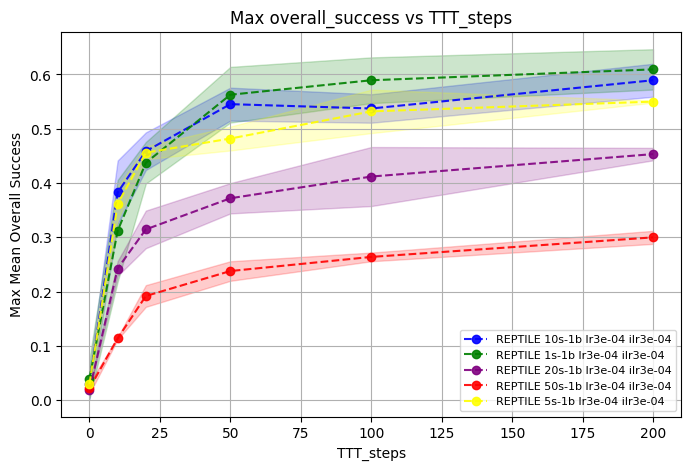

In [ ]:
REPTILE_FROM_SCRATCH = {
    "REPTILE 1s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"TEST-antmaze-ddpgbc-RX-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
            "color": "green",
            "linestyle": "--",
            "dot_type": "o",
        },
    "REPTILE 5s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"TEST-antmaze-ddpgbc-RX-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
            "color": "yellow",
            "linestyle": "--",
            "dot_type": "o",
        },
    "REPTILE 10s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"TEST-antmaze-ddpgbc-RX-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
            "color": "blue",
            "linestyle": "--",
            "dot_type": "o",
        },
    "REPTILE 20s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"TEST-antmaze-ddpgbc-RX-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
            "color": "purple",
            "linestyle": "--",
            "dot_type": "o",
        },
    "REPTILE 50s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"TEST-antmaze-ddpgbc-RX-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
            "color": "red",
            "linestyle": "--",
            "dot_type": "o",
    }
}

plot_max_overall_success_vs_ttt_steps(REPTILE_FROM_SCRATCH)

# Finetuned

{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'PT', 'inner_steps': None, 'meta_batch_size': None, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 3e-05, 'ilr': 3e-05}
{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'PT', 'inner_steps': None, 'meta_batch_size': None, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': 'FT', 'goals': 'TEST', 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'PT', 'inner_steps': None, 'meta_batch_size': None, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.003, 'ilr': 0.003}
{'is_finetuned': None, 'goals': None, 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 'PT', 'inner_steps': None, 'meta_batch_size': None, 'mc_quantile': 0.2, 'merging_eps': None, 'lr': 0.0003, 'ilr': 0.0003}
{'is_finetuned': None, 'goals': None, 'env': 'antmaze', 'policy_extraction': 'ddpgbc', 'pretraining': 

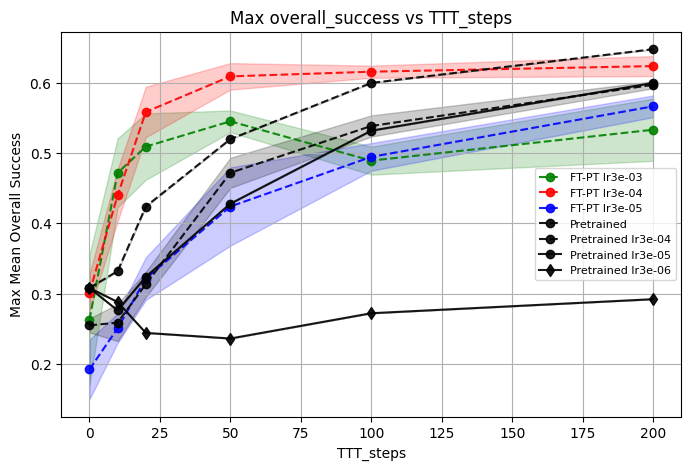

In [8]:
ANTMAZE_FINETUNED = {}
ANTMAZE_FINETUNED["FX"] = {
        f"FT FOMAML 1s-1b lr3e-05 ilr3e-05": {
            "groups": [
                f"FT-TEST-antmaze-ddpgbc-FX-1-1-mc0.2-lr3e-05-ilr3e-05"
            ],
            "color": "blue",
            "linestyle": "--",
            "dot_type": "o",
        },

        f"FT FOMAML 1s-1b lr3e-04 ilr3e-05": {
            "groups": [
                f"FT-TEST-antmaze-ddpgbc-FX-1-1-mc0.2-lr0.0003-ilr3e-05"
            ],
            "color": "red",
            "linestyle": "--",
            "dot_type": "o",
        },

        f"FT FOMAML 1s-1b lr3e-04 ilr3e-04": {
            "groups": [
                f"FT-TEST-antmaze-ddpgbc-FX-1-1-mc0.2-lr0.0003-ilr0.0003"
            ],
            "color": "green",
            "linestyle": "--",
            "dot_type": "o",
        },
    }

ANTMAZE_FINETUNED["RX"] = {
    f"FT REPTILE 1s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    f"FT REPTILE 5s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-5-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "-",
        "dot_type": "o",
    },

    f"FT REPTILE 5s-1b lr3e-05 ilr3e-05": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-5-1-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "d",
    },

    f"FT REPTILE 10s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-10-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },

    f"FT REPTILE 10s-1b lr3e-05 ilr3e-05": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-10-1-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "d",
    },

    f"FT REPTILE 20s-1b lr3e-05 ilr3e-05": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-20-1-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "d",
    },

    f"FT REPTILE 20s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-20-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },

    f"FT REPTILE 50s-1b lr3e-05 ilr3e-05": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-50-1-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "d",
    },

    f"FT REPTILE 50s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-50-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },

    f"FT REPTILE 100s-1b lr3e-05 ilr3e-05": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-100-1-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "d",
    },

    f"FT REPTILE 100s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-100-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "-",
        "dot_type": "o",
    },



    "Pretrained": {
        "groups": [
            "antmaze-ddpgbc-PT"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },

    "FT-PT lr3e-04": {
        "groups": [
            "FT-TEST-antmaze-ddpgbc-PT-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },
}

ANTMAZE_FINETUNED["PT"] = {
    "FT-PT lr3e-05": {
        "groups": [
            "FT-TEST-antmaze-ddpgbc-PT-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },
    "FT-PT lr3e-04": {
        "groups": [
            "FT-TEST-antmaze-ddpgbc-PT-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },
    "FT-PT lr3e-03": {
        "groups": [
            "FT-TEST-antmaze-ddpgbc-PT-mc0.2-lr0.003-ilr0.003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },

    "Pretrained": {
        "groups": [
            "antmaze-ddpgbc-PT"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },


    "Pretrained lr3e-04": {
        "groups": [
            "antmaze-ddpgbc-PT-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "black",
        "linestyle": "--",
        "dot_type": "o",
    },
    "Pretrained lr3e-05": {
        "groups": [
            "antmaze-ddpgbc-PT-mc0.2-lr3e-05-ilr3e-05"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "o",
    },

    "Pretrained lr3e-06": {
        "groups": [
            "antmaze-ddpgbc-PT-mc0.2-lr3e-06-ilr3e-06"
        ],
        "color": "black",
        "linestyle": "-",
        "dot_type": "d",
    },
}


ANTMAZE_COMPARISON_FT = {
    f"FT-FOMAML 1s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-FX-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "red",
        "linestyle": "--",
        "dot_type": "o",
    },
    f"FT-REPTILE 1s-1b lr3e-04 ilr3e-04": {
        "groups": [
            f"FT-TEST-antmaze-ddpgbc-RX-1-1-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "blue",
        "linestyle": "--",
        "dot_type": "o",
    },
    "FT-PT lr3e-04": {
        "groups": [
            "FT-TEST-antmaze-ddpgbc-PT-mc0.2-lr0.0003-ilr0.0003"
        ],
        "color": "green",
        "linestyle": "--",
        "dot_type": "o",
    },
}
# plot_overall_success_for_groups(ANTMAZE_FROM_SCRATCH["FX"])
plot_max_overall_success_vs_ttt_steps(ANTMAZE_FINETUNED["PT"])